In [22]:
import pandas as pd
from glob import glob
import os
import json

In [96]:
dfs = []
for json_path in glob('./logs/finetune_cpb_20250814/*/*/*/*/*/*/*.json'):
    
    path_parts = json_path.split('/')
    model = path_parts[3]
    weights = path_parts[4]
    method = path_parts[-5]
    n_train = int(path_parts[-4].split('_')[-1])
    rep = int(path_parts[-3].split('_')[-1])
    fold = int(path_parts[-2].split('_')[-1])
    
    # print(f'Processing {method} rep {rep} fold {fold} with {n_train} training samples')
    metrics_data = json.load(open(json_path, 'r'))
    metrics_data['model'] = model
    metrics_data['weights'] = weights
    metrics_data['method'] = method
    metrics_data['n_train'] = n_train
    metrics_data['rep'] = rep
    metrics_data['fold'] = fold
    dfs.append(pd.DataFrame(metrics_data, index=[0]))

metrics_df = pd.concat(dfs, ignore_index=True)
display(metrics_df)

,accuracy,f1_score,precision,recall,jaccard,kappa,macro_f1_score,macro_precision,macro_recall,macro_jaccard,weighted_f1_score,weighted_precision,weighted_recall,weighted_jaccard,model,weights,method,n_train,rep,fold
0,0.866605,0.861296,0.861147,0.866605,0.772750,0.919744,0.649709,0.749110,0.619039,0.524582,0.861296,0.861147,0.866605,0.772750,deeplabv3plus,imagenet,srs,500,2,4
1,0.865999,0.863784,0.865266,0.865999,0.775827,0.918495,0.650537,0.742499,0.622086,0.529494,0.863784,0.865266,0.865999,0.775827,deeplabv3plus,imagenet,srs,500,2,3
2,0.870716,0.867029,0.866969,0.870716,0.780526,0.921938,0.657757,0.753311,0.620135,0.534788,0.867029,0.866969,0.870716,0.780526,deeplabv3plus,imagenet,srs,500,2,2
3,0.870978,0.867389,0.866086,0.870978,0.781046,0.922064,0.670144,0.734262,0.639757,0.544337,0.867389,0.866086,0.870978,0.781046,deeplabv3plus,imagenet,srs,500,2,1
4,0.871395,0.867072,0.866456,0.871395,0.780189,0.922463,0.677873,0.752449,0.652433,0.552909,0.867072,0.866456,0.871395,0.780189,deeplabv3plus,imagenet,srs,500,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,0.864827,0.861118,0.861869,0.864827,0.771933,0.918424,0.662334,0.762102,0.625670,0.534578,0.861118,0.861869,0.864827,0.771933,deeplabv3plus,imagenet,semss,250,1,1
143,0.860148,0.855431,0.854816,0.860148,0.764798,0.915561,0.633723,0.724421,0.608275,0.514123,0.855431,0.854816,0.860148,0.764798,deeplabv3plus,imagenet,semss,250,0,4
144,0.860638,0.856689,0.855518,0.860638,0.765114,0.916008,0.677099,0.735967,0.643570,0.544589,0.856689,0.855518,0.860638,0.765114,deeplabv3plus,imagenet,semss,250,0,3
145,0.858543,0.853904,0.853907,0.858543,0.762418,0.914660,0.640875,0.717571,0.611587,0.512371,0.853904,0.853907,0.858543,0.762418,deeplabv3plus,imagenet,semss,250,0,2


In [97]:
# metrics_df.loc[(metrics_df.weights == 'none') & (metrics_df.rep <= 1)].groupby(['model', 'weights', 'method', 'n_train']).max().sort_values(by='macro_jaccard', ascending=False)
metrics_df.loc[(metrics_df.rep <= 3)].groupby(['model', 'weights', 'method', 'n_train']).max().sort_values(by='macro_jaccard', ascending=False)

accuracy  f1_score  precision  \
model         weights  method n_train                                  
deeplabv3plus imagenet srs    750      0.878678  0.876045   0.875297   
                       semss  750      0.878733  0.875968   0.875570   
                       sss    750      0.875324  0.871889   0.870778   
                       semss  500      0.876091  0.873466   0.873853   
                       sss    500      0.872969  0.869603   0.868771   
                       srs    500      0.873423  0.869925   0.868737   
                       semss  250      0.866712  0.861763   0.861869   
                       sss    250      0.864736  0.860304   0.858756   
                       srs    250      0.864274  0.858894   0.858051   

                                         recall   jaccard     kappa  \
model         weights  method n_train                                 
deeplabv3plus imagenet srs    750      0.878678  0.792507  0.926615   
                       semss  750      0.878733  0.792159  0.926698   
                       sss    750      0.875324  0.786763  0.924739   
                       semss  500      0.876091  0.788874  0.924995   
                       sss    500      0.872969  0.784161  0.923231   
                       srs    500      0.873423  0.784434  0.923501   
                       semss  250      0.866712  0.773922  0.919638   
                       sss    250      0.864736  0.771173  0.918563   
                       srs    250      0.864274  0.770131  0.918219   

                                       macro_f1_score  macro_precision  \
model         weights  method n_train                                    
deeplabv3plus imagenet srs    750            0.716547         0.759943   
                       semss  750            0.719094         0.775089   
                       sss    750            0.703498         0.759512   
                       semss  500            0.704243         0.782238   
                       sss    500            0.691403         0.753427   
                       srs    500            0.688320         0.753311   
                       semss  250            0.677099         0.770841   
                       sss    250            0.663965         0.745888   
                       srs    250            0.650425         0.742703   

                                       macro_recall  macro_jaccard  \
model         weights  method n_train                                
deeplabv3plus imagenet srs    750          0.695945       0.586132   
                       semss  750          0.697405       0.585012   
                       sss    750          0.672152       0.572288   
                       semss  500          0.671344       0.569556   
                       sss    500          0.661918       0.561155   
                       srs    500          0.662229       0.557091   
                       semss  250          0.643570       0.544589   
                       sss    250          0.632901       0.534659   
                       srs    250          0.622402       0.520082   

                                       weighted_f1_score  weighted_precision  \
model         weights  method n_train                                          
deeplabv3plus imagenet srs    750               0.876045            0.875297   
                       semss  750               0.875968            0.875570   
                       sss    750               0.871889            0.870778   
                       semss  500               0.873466            0.873853   
                       sss    500               0.869603            0.868771   
                       srs    500               0.869925            0.868737   
                       semss  250               0.861763            0.861869   
                       sss    250               0.860304            0.858756   
                       srs    250               0.858894            0.858051  

In [98]:
metrics_df

,accuracy,f1_score,precision,recall,jaccard,kappa,macro_f1_score,macro_precision,macro_recall,macro_jaccard,weighted_f1_score,weighted_precision,weighted_recall,weighted_jaccard,model,weights,method,n_train,rep,fold
0,0.866605,0.861296,0.861147,0.866605,0.772750,0.919744,0.649709,0.749110,0.619039,0.524582,0.861296,0.861147,0.866605,0.772750,deeplabv3plus,imagenet,srs,500,2,4
1,0.865999,0.863784,0.865266,0.865999,0.775827,0.918495,0.650537,0.742499,0.622086,0.529494,0.863784,0.865266,0.865999,0.775827,deeplabv3plus,imagenet,srs,500,2,3
2,0.870716,0.867029,0.866969,0.870716,0.780526,0.921938,0.657757,0.753311,0.620135,0.534788,0.867029,0.866969,0.870716,0.780526,deeplabv3plus,imagenet,srs,500,2,2
3,0.870978,0.867389,0.866086,0.870978,0.781046,0.922064,0.670144,0.734262,0.639757,0.544337,0.867389,0.866086,0.870978,0.781046,deeplabv3plus,imagenet,srs,500,2,1
4,0.871395,0.867072,0.866456,0.871395,0.780189,0.922463,0.677873,0.752449,0.652433,0.552909,0.867072,0.866456,0.871395,0.780189,deeplabv3plus,imagenet,srs,500,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,0.864827,0.861118,0.861869,0.864827,0.771933,0.918424,0.662334,0.762102,0.625670,0.534578,0.861118,0.861869,0.864827,0.771933,deeplabv3plus,imagenet,semss,250,1,1
143,0.860148,0.855431,0.854816,0.860148,0.764798,0.915561,0.633723,0.724421,0.608275,0.514123,0.855431,0.854816,0.860148,0.764798,deeplabv3plus,imagenet,semss,250,0,4
144,0.860638,0.856689,0.855518,0.860638,0.765114,0.916008,0.677099,0.735967,0.643570,0.544589,0.856689,0.855518,0.860638,0.765114,deeplabv3plus,imagenet,semss,250,0,3
145,0.858543,0.853904,0.853907,0.858543,0.762418,0.914660,0.640875,0.717571,0.611587,0.512371,0.853904,0.853907,0.858543,0.762418,deeplabv3plus,imagenet,semss,250,0,2


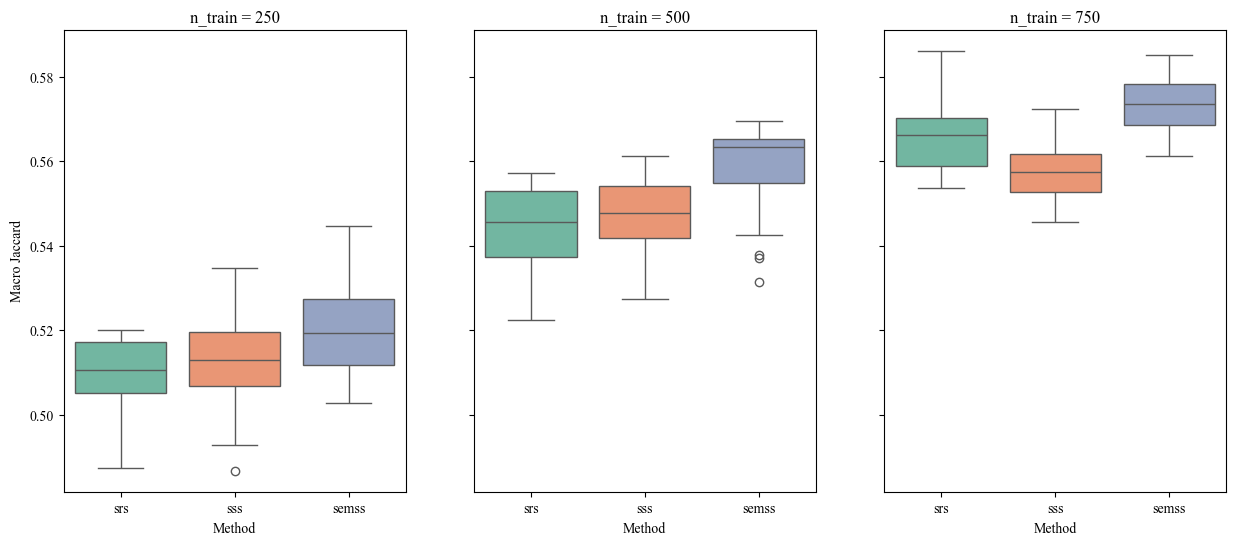

In [99]:
# create boxplot
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'

df = metrics_df.copy()
# df = df[df.weights == 'none']
df = df.loc[df.rep <= 3]
fig, ax = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
n_train_values = [250, 500, 750]
for i, n_train in enumerate(n_train_values):
    sns.boxplot(data=df[df.n_train == n_train], x='method', y='macro_jaccard', ax=ax[i], palette='Set2', hue='method', legend=False)
    ax[i].set_title(f'n_train = {n_train}')
    ax[i].set_ylabel('Macro Jaccard')
    ax[i].set_xlabel('Method')

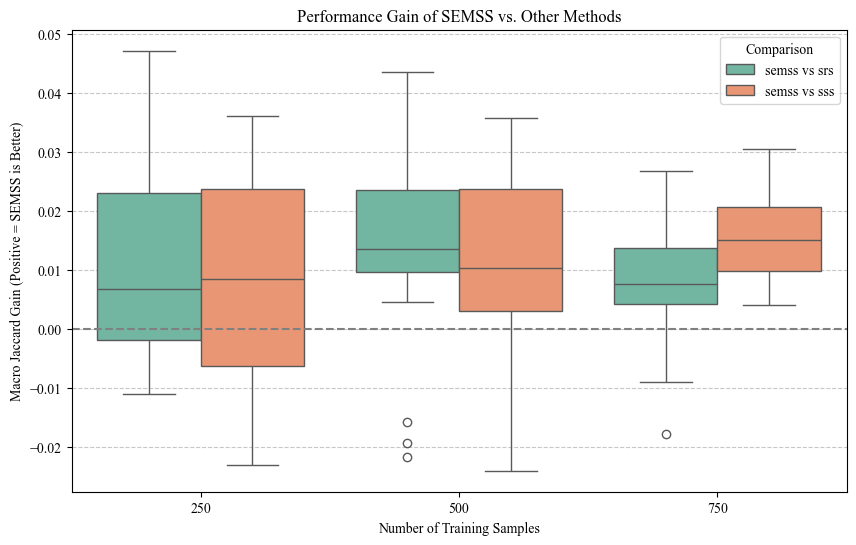

In [100]:

# Create a plot to emphasize the performance gain of SEMSS
df_pivot = df.pivot_table(index=['n_train', 'rep', 'fold'], columns='method', values='macro_jaccard').reset_index()

# Calculate the performance gain of semss over the other methods
df_pivot['semss_gain_vs_srs'] = df_pivot['semss'] - df_pivot['srs']
df_pivot['semss_gain_vs_sss'] = df_pivot['semss'] - df_pivot['sss']

# Melt the dataframe to make it suitable for plotting with seaborn
df_gain = df_pivot.melt(
    id_vars=['n_train'], 
    value_vars=['semss_gain_vs_srs', 'semss_gain_vs_sss'],
    var_name='comparison',
    value_name='macro_jaccard_gain'
)
df_gain['comparison'] = df_gain['comparison'].str.replace('semss_gain_vs_', 'semss vs ')

# Create the plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_gain, x='n_train', y='macro_jaccard_gain', hue='comparison', palette='Set2')
plt.axhline(0, color='grey', linestyle='--')
plt.title('Performance Gain of SEMSS vs. Other Methods')
plt.xlabel('Number of Training Samples')
plt.ylabel('Macro Jaccard Gain (Positive = SEMSS is Better)')
plt.legend(title='Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
